In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Ecommerce_Data-1.csv")

In [4]:
df.head()

,Unnamed: 0,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Hour
0,439570,574477,22591,CARDHOLDER GINGHAM CHRISTMAS TREE,1,3.25,15453,United Kingdom,11/4/2011,12
1,387281,570275,23541,WALL ART CLASSIC PUDDINGS,12,7.45,13098,United Kingdom,10/10/2011,10
2,337863,566482,22508,DOORSTOP RETROSPOT HEART,12,3.75,16609,United Kingdom,9/13/2011,9
3,57628,541215,22662,LUNCH BAG DOLLY GIRL DESIGN,10,1.65,14329,United Kingdom,1/14/2011,13
4,330897,565930,POST,POSTAGE,5,18.00,12685,France,9/8/2011,10


In [5]:
print(df.shape)
print(df.info())
print(df.describe())

(81601, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81601 entries, 0 to 81600
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   81601 non-null  int64  
 1   InvoiceNo    81601 non-null  object 
 2   StockCode    81601 non-null  object 
 3   Description  81601 non-null  object 
 4   Quantity     81601 non-null  int64  
 5   UnitPrice    81601 non-null  float64
 6   CustomerID   81601 non-null  int64  
 7   Country      81601 non-null  object 
 8   Date         81601 non-null  object 
 9   Hour         81601 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 6.2+ MB
None
          Unnamed: 0      Quantity     UnitPrice    CustomerID          Hour
count   81601.000000  81601.000000  81601.000000  81601.000000  81601.000000
mean   278271.366772     11.965736      3.168721  15283.816215     12.729783
std    152483.054308     45.782018     18.731668   1713.292081      2.288777


In [6]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Hour
0,574477,22591,CARDHOLDER GINGHAM CHRISTMAS TREE,1,3.25,15453,United Kingdom,11/4/2011,12
1,570275,23541,WALL ART CLASSIC PUDDINGS,12,7.45,13098,United Kingdom,10/10/2011,10
2,566482,22508,DOORSTOP RETROSPOT HEART,12,3.75,16609,United Kingdom,9/13/2011,9
3,541215,22662,LUNCH BAG DOLLY GIRL DESIGN,10,1.65,14329,United Kingdom,1/14/2011,13
4,565930,POST,POSTAGE,5,18.00,12685,France,9/8/2011,10


In [8]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
UnitPrice      0
CustomerID     0
Country        0
Date           0
Hour           0
dtype: int64

In [9]:
df.duplicated().sum()
df = df.drop_duplicates()

In [10]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [11]:
df["Total Price"] = df["Quantity"] * df["UnitPrice"]

In [28]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

In [29]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Hour,Total Price,Weekday,Month
0,574477,22591,CARDHOLDER GINGHAM CHRISTMAS TREE,1,3.25,15453,United Kingdom,2011-11-04,12,3.25,Friday,11
1,570275,23541,WALL ART CLASSIC PUDDINGS,12,7.45,13098,United Kingdom,2011-10-10,10,89.40,Monday,10
2,566482,22508,DOORSTOP RETROSPOT HEART,12,3.75,16609,United Kingdom,2011-09-13,9,45.00,Tuesday,9
3,541215,22662,LUNCH BAG DOLLY GIRL DESIGN,10,1.65,14329,United Kingdom,2011-01-14,13,16.50,Friday,1
4,565930,POST,POSTAGE,5,18.00,12685,France,2011-09-08,10,90.00,Thursday,9


In [13]:
df["Weekday"] = pd.to_datetime(df["Date"]).dt.day_name()

### Exploratory Data Analysis (EDA)

### General stats

In [14]:
print(df["Country"].value_counts())
print(df["Description"].value_counts().head(5))

Country
United Kingdom          70867
Germany                  1816
France                   1653
EIRE                     1454
Spain                     490
Netherlands               466
Belgium                   373
Switzerland               352
Portugal                  281
Australia                 238
Norway                    211
Italy                     162
Finland                   157
Channel Islands           155
Cyprus                    117
Sweden                     98
Austria                    98
Denmark                    81
Japan                      80
Poland                     56
Unspecified                55
Iceland                    48
Israel                     45
Singapore                  40
USA                        39
Greece                     34
Malta                      26
Canada                     23
RSA                        14
United Arab Emirates       14
European Community         11
Czech Republic              8
Lithuania                   6
Br

### Sales Analysis

In [30]:
# Total Revenue
print(df["Total Price"].sum())

# Revenue by Country
country_sales = df.groupby("Country")["Total Price"].sum().sort_values(ascending=False)
print(country_sales)

# Revenue by Month
Monthly_sales = df.groupby("Month")["Total Price"].sum()
print(Monthly_sales)

1708746.511
Country
United Kingdom          1403367.411
EIRE                      53116.680
Netherlands               52680.640
Germany                   44284.800
France                    39419.040
Australia                 24775.310
Spain                     10949.780
Switzerland               10515.160
Sweden                     9590.390
Belgium                    7541.880
Norway                     7176.500
Japan                      6757.220
Portugal                   5801.830
Finland                    5253.250
Channel Islands            4681.580
Italy                      3778.140
Denmark                    2753.460
Austria                    2657.840
Cyprus                     2293.250
Singapore                  1649.760
Israel                     1480.520
Poland                     1330.880
Iceland                    1146.590
Greece                     1071.780
Canada                      884.350
USA                         788.210
Unspecified                 591.490
Malta   

In [31]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Date,Hour,Total Price,Weekday,Month
0,574477,22591,CARDHOLDER GINGHAM CHRISTMAS TREE,1,3.25,15453,United Kingdom,2011-11-04,12,3.25,Friday,11
1,570275,23541,WALL ART CLASSIC PUDDINGS,12,7.45,13098,United Kingdom,2011-10-10,10,89.40,Monday,10
2,566482,22508,DOORSTOP RETROSPOT HEART,12,3.75,16609,United Kingdom,2011-09-13,9,45.00,Tuesday,9
3,541215,22662,LUNCH BAG DOLLY GIRL DESIGN,10,1.65,14329,United Kingdom,2011-01-14,13,16.50,Friday,1
4,565930,POST,POSTAGE,5,18.00,12685,France,2011-09-08,10,90.00,Thursday,9


### Customer analysis

In [32]:
# Unique customers
print(len(set(df["CustomerID"])))

# Average order value
avg_order = df.groupby("InvoiceNo")["Total Price"].sum().mean()
print(avg_order)

# Orders per customer
orders_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()
print(orders_per_customer)

4094
110.51264461259862
CustomerID
12347     7
12348     4
12349     1
12350     1
12352     6
         ..
18280     1
18281     1
18282     2
18283    14
18287     2
Name: InvoiceNo, Length: 4094, dtype: int64


### Product Analysis

In [24]:
# Most sold products
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)
print(top_products)
# Highest revenue products
top_revenue_products = df.groupby("Description")["Total Price"].sum().sort_values(ascending=False)
print(top_revenue_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     9047
POPCORN HOLDER                        8513
ASSORTED COLOUR BIRD ORNAMENT         7020
JUMBO BAG RED RETROSPOT               6973
FAIRY CAKE FLANNEL ASSORTED COLOUR    6902
                                      ... 
LETTER "H" BLING KEY RING                1
FLOWER PURPLE CLOCK WITH SUCKER          1
LETTER "B" BLING KEY RING                1
FLOWER SHOP DESIGN MUG                   1
BEACH HUT KEY CABINET                    1
Name: Quantity, Length: 3409, dtype: int64
Description
REGENCY CAKESTAND 3 TIER              25376.94
WHITE HANGING HEART T-LIGHT HOLDER    17665.19
PARTY BUNTING                         16403.16
FAIRY CAKE FLANNEL ASSORTED COLOUR    13912.39
POSTAGE                               13189.39
                                        ...   
A4 WALL TIDY RED FLOWERS                  0.53
ELEPHANT CLIP W SUCTION CUP               0.42
BLUE/YELLOW FLOWER DESIGN BIG MUG         0.39
PINK BREAKFAST CUP AND SAUCER        

### Time Analysis

In [25]:
# Sales by weekday
weekday_sales = df.groupby("Weekday")["Total Price"].sum()
print(weekday_sales)

# Sales by hour
hourly_sales = df.groupby("Hour")["Total Price"].sum()
print(hourly_sales)

Weekday
Friday       248652.750
Monday       288149.121
Sunday       159714.610
Thursday     380345.990
Tuesday      321713.340
Wednesday    310170.700
Name: Total Price, dtype: float64
Hour
7       5807.580
8      59070.490
9     133585.830
10    227548.810
11    222186.580
12    276319.610
13    241022.600
14    192080.700
15    183490.930
16     84946.540
17     50009.111
18     20698.250
19      8177.930
20      3801.550
Name: Total Price, dtype: float64


## Visualization

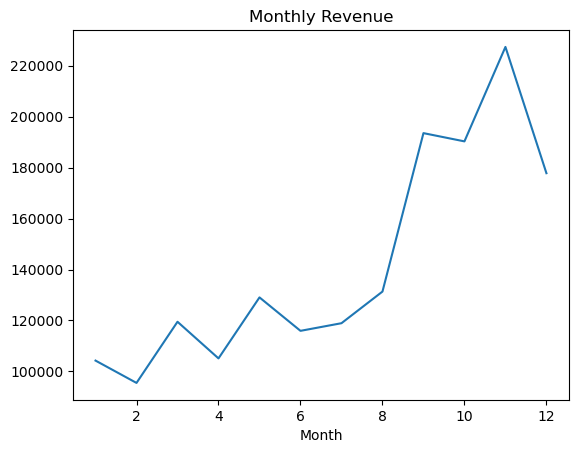

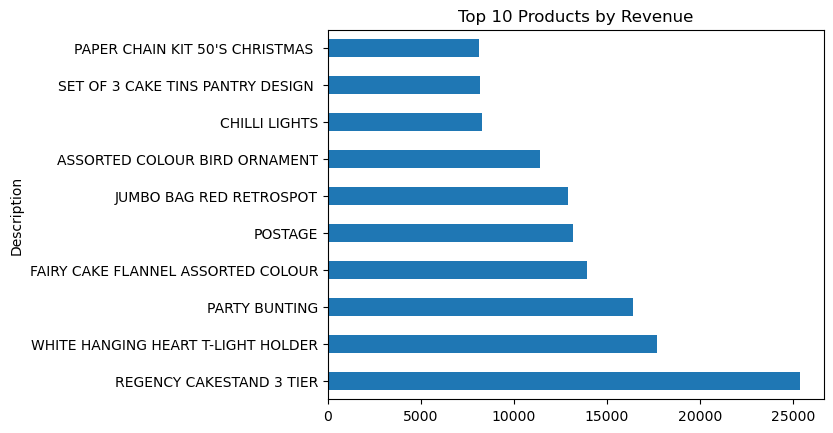

<function matplotlib.pyplot.show(close=None, block=None)>

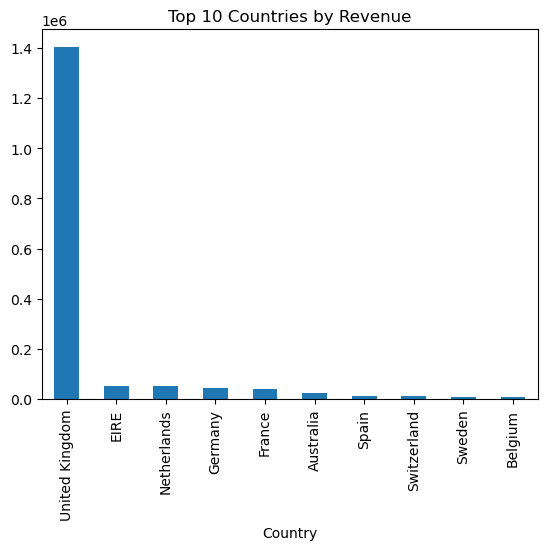

In [33]:
# Monthly sales trend
Monthly_sales.plot(kind = "line", title = "Monthly Revenue")
plt.show()

# Top 10 Products by revenue
top_revenue_products.head(10).plot(kind = "barh", title = "Top 10 Products by Revenue")
plt.show()

# Sales by country
country_sales.head(10).plot(kind = "bar", title = "Top 10 Countries by Revenue")
plt.show